# Data Preprocessing

## Objective

The objective of this notebook is to prepare the cleaned dataset for machine learning.

The preprocessing steps include:

- Preparing the target variable
- Handling categorical features
- Transforming specific variables
- Preparing data for feature engineering and modeling

*1.import libraries*

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

*2. Load Clean Dataset*

In [9]:
df = pd.read_csv('../data/processed/clean_data.csv')

*3. Prepare Target Variable*

In [10]:
df["readmitted"] = df["readmitted"].replace({
    "NO": 0,
    ">30": 1,
    "<30": 2
})

df["readmitted"].value_counts()

C:\Users\MINA\AppData\Local\Temp\ipykernel_21616\3059095660.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["readmitted"] = df["readmitted"].replace({


readmitted
0    54864
1    35545
2    11357
Name: count, dtype: int64

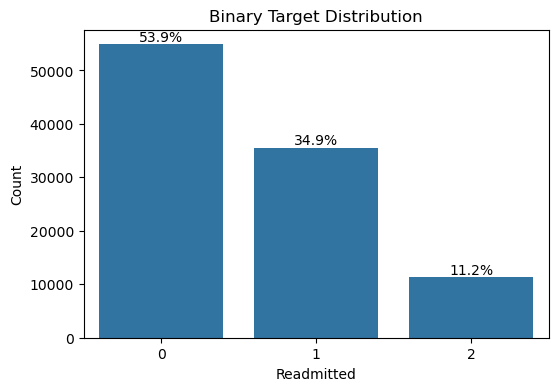

In [11]:
plt.figure(figsize=(6,4))

ax = sns.countplot(
    data=df,
    x="readmitted"
)

total = len(df)

for p in ax.patches:
    
    percentage = 100 * p.get_height() / total
    
    ax.annotate(
        f"{percentage:.1f}%",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.title("Binary Target Distribution")
plt.xlabel("Readmitted")
plt.ylabel("Count")

plt.show()

**trasnform age to namber unit**

In [12]:
df["age"] = (
    df["age"]
      .str.extract(r"(\d+)")
      .astype(int)
      .add(5)
)

df["age"].head()

0     5
1    15
2    25
3    35
4    45
Name: age, dtype: int32

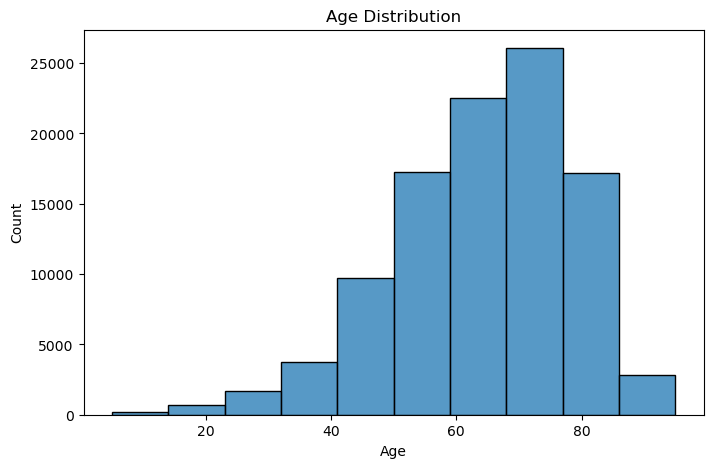

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="age",
    bins=10
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

## save of data ##

In [18]:
df.to_csv(
    "../data/processed/preprocessing.csv",
    index=False
)

## Summary of Changes

The following preprocessing steps were completed:

- Converted the target variable (`readmitted`) into a binary classification problem.
- Mapped:
  - `NO` → 0
  - `>30` → 1
  - `<30` → 2
- Converted age intervals into numerical midpoint values.
- Verified the resulting distributions after transformation.
- Saved the preprocessed dataset for feature engineering.